In [1]:
from lifelines import CoxPHFitter
from lifelines import KaplanMeierFitter
from lifelines.utils import concordance_index
from lifelines.plotting import add_at_risk_counts
from lifelines.statistics import pairwise_logrank_test
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
import seaborn as sns
from skbio.stats.composition import clr
from sklearn.preprocessing import normalize
from sklearn.utils import resample
import time

import warnings
warnings.filterwarnings("ignore", message="FutureWarning")

import sys
main_path = '/Users/Kai/HPL-LATTICeA'

sys.path.append(main_path)
from libraries.survival import *
from libraries.clinical import load_clinical
from libraries.data_processing import *
from libraries.forest_plots import *

In [2]:
meta_folder        = 'rapids_2p5m'
matching_field     = 'samples'
event_ind_field    = 'os_event_ind'
event_data_field   = 'os_event_data'
diversity_key      = None
type_composition   = 'clr'
min_tiles          = 100
folds_pickle       = os.path.join(main_path, 'utilities/fold_creation/lattice_5x_folds.pkl')
force_fold         = 2
h5_complete_path   = os.path.join(main_path, 'results/BarlowTwins_3/LATTICeA_5x/h224_w224_n3_zdim128_filtered/hdf5_LATTICeA_5x_he_complete_filtered.h5')
h5_additional_path = os.path.join(main_path, 'results/BarlowTwins_3/LATTICeA_5x/h224_w224_n3_zdim128_filtered/hdf5_TCGA_LUAD_5x_he_train_filtered.h5')
additional_as_fold = False
report_clusters    = False

max_months        = 60
use_conn          = False
use_ratio         = False
top_variance_feat = 99

l1_ratios   = [0.0]
if len(l1_ratios) == 1:
    l1_ratio = l1_ratios[0]
    
resolutions = [2.5]
if len(resolutions) == 1:
    resolution = resolutions[0]

main_cluster_path = h5_complete_path.split('hdf5_')[0]
main_cluster_path = os.path.join(main_path, main_cluster_path, meta_folder)
adatas_path       = os.path.join(main_cluster_path, 'adatas')

In [3]:
# Feature selection
leiden_clusters, malignant_clusters, stromal_clusters = load_topography(main_path=main_path)

# Get clinical data
clinpath, survival, patterns_samples = load_clinical(main_path=main_path)
survival = survival.merge(patterns_samples[['samples', 'iaslc_grade']], on='samples')
survival

/Users/Kai/HPL-LATTICeA/libraries/clinical.py:8: DtypeWarning: Columns (2,10,30,37,38,52,67,84,85,110,118,134,135,136,137,138,148,149,150,217,219,221,223,224,225,226,236,242,243,244,245,248,249,250,251,252,253,254,255,256,257,261,262,263,264,265,266,267,268,269,270,271,280,282,283,285,288,289,294,295,298,299,310,311,312,313,314,315,316,317,340,374,440,441,442,443,446,447,448,449,450,451,452,453,454,455,459,460,461,462,463,464,465,466,467,468,469,481,487,508,509,510,511,512,513,514,515,538,572,638,639,640,641,644,645,646,647,648,649,650,651,652,653,657,658,659,660,661,662,663,664,665,666,667,679,685,706,707,708,709,710,711,712,713,736,770,834,835,836,839,863,887) have mixed types. Specify dtype option on import or set low_memory=False.
  clinpath = pd.read_csv(os.path.join(main_path, 'utilities/files/LUAD-LATTICeA/latticea_master_clinicopathological.csv'))
/Users/Kai/HPL-LATTICeA/libraries/clinical.py:79: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed

,index,sample_ID,Originator,Checked,Pathology Number,Case Number,male,Complete?,Receipt Delay (Days),age,...,Invasion.10,Donor Block Number.11,Core Row.11,Core Column.11,Invasion.11,Complete?.6,samples,stage_num,PDL_positive,iaslc_grade
0,11,13,ms831,crs20,PR022438N/10,2,0,Incomplete,0,76,...,NaN,NaN,NaN,NaN,NaN,Incomplete,ACA_0002,1,NaN,3
1,253,14,ms831,crs20,PR025028M/10,3,1,Incomplete,1,77,...,NaN,NaN,NaN,NaN,NaN,Incomplete,ACA_0003,1,0.0,2
2,14,18,ms831,crs20,PR026550L/10,4,0,Incomplete,1,61,...,NaN,NaN,NaN,NaN,NaN,Incomplete,ACA_0004,3,0.0,3
3,133,27,ms831,crs20,PR029768B/10,5,0,Incomplete,0,64,...,NaN,NaN,NaN,NaN,NaN,Incomplete,ACA_0005,1,0.0,1
4,34,40,crs20,ms831,PR030965Y/10,6,0,Incomplete,1,81,...,NaN,NaN,NaN,NaN,NaN,Incomplete,ACA_0006,2,0.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
798,1020,1054,ms831,NaN,PR051543M/15,1108,0,Incomplete,0,61,...,NaN,NaN,NaN,NaN,NaN,Incomplete,ACA_1108,1,0.0,3
799,1021,1055,ms831,NaN,PR051580N/15,1109,1,Incomplete,4,83,...,NaN,NaN,NaN,NaN,NaN,Incomplete,ACA_1109,1,0.0,3
800,1022,1056,ms831,NaN,PR051863R/15,1110,0,Incomplete,0,71,...,NaN,NaN,NaN,NaN,NaN,Incomplete,ACA_1110,2,1.0,3
801,1023,1057,ms831,NaN,PR052068K/15,1112,1,Incomplete,0,65,...,NaN,NaN,NaN,NaN,NaN,Incomplete,ACA_1112,1,0.0,3


In [4]:
groupby     = f'leiden_{resolution}'

main_cluster_path = h5_complete_path.split('hdf5_')[0]
main_cluster_path = os.path.join(main_cluster_path, meta_folder)
adatas_path       = os.path.join(main_cluster_path, 'adatas')

In [5]:
complete_df, additional_df, leiden_clusters = read_csvs_forcefold(adatas_path=os.path.join(main_path, 'data/vanilla-hpc'), groupby=groupby, h5_complete_path=h5_complete_path, h5_additional_path=h5_additional_path, force_fold=2)

In [6]:
sample_rep_df = generate_frequency_vector(complete_df=complete_df, matching_field='samples', groupby=groupby, leiden_clusters=list(stromal_clusters), transform=True)
sample_rep_df

,1,2,3,10,14,15,16,18,23,25,26,32,42,43,55,56,59,60,samples
0,0.364836,-1.959146,-0.178780,0.692048,-1.959146,0.541766,2.891854,-0.766567,-1.959146,-0.296563,-1.959146,0.514367,0.956200,2.048842,-1.682857,0.842871,0.715038,1.193528,ACA_0193
1,-0.510502,-0.135809,-1.298960,2.389920,-2.030086,0.310478,0.702520,-0.828956,0.182645,1.116954,-2.030086,1.473629,-0.200348,1.613391,-2.908398,0.269656,-0.343448,2.227401,ACA_0324
2,0.205659,-0.487488,-1.873782,-0.487488,-2.006427,1.863888,2.203755,0.072128,0.323442,-0.082023,-2.006427,0.072128,-0.775170,0.323442,-1.873782,2.592126,0.765275,1.170740,ACA_0476
3,-0.934929,0.440894,-0.105650,1.455362,-1.915758,-0.221163,0.204505,1.074403,-1.473926,0.430312,-1.404933,0.917455,-1.117251,1.350849,0.375653,0.631949,-0.557635,0.849862,ACA_0837
4,-0.290476,1.383501,-1.854104,2.012110,-1.854104,0.962287,2.653963,-0.472797,0.402672,2.299792,-1.854104,-0.290476,-2.082235,-1.389088,-1.854104,1.555351,-0.136325,0.808137,ACA_0574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002,0.521536,-1.637949,0.398933,0.036028,-3.835173,2.120664,-0.401186,-2.736561,0.135119,-1.437278,0.482315,0.571546,1.246231,1.649624,-0.839441,2.228612,0.799556,0.697426,ACA_0779
1003,-0.285764,-0.873551,-1.789842,1.448837,-1.997243,-0.691229,1.765507,-1.789842,0.849216,-0.873551,0.081961,1.278211,-0.285764,1.254681,-2.482989,2.731947,0.775108,0.884307,ACA_0626
1004,2.242945,-1.842913,1.349127,-1.842913,-1.842913,2.658461,-1.253562,-1.253562,1.144333,-1.842913,-0.000799,0.355876,2.287397,1.049023,-1.946710,-0.154950,0.761341,0.132732,ACA_0656
1005,0.776799,1.875411,-1.577746,-1.577746,-1.577746,0.083652,2.163093,0.083652,3.028091,-1.577746,0.776799,-1.577746,-1.577746,-1.577746,-1.577746,2.974023,0.083652,0.776799,ACA_0406


In [7]:
additional_rep_df = generate_frequency_vector(complete_df=additional_df, matching_field='samples', groupby=groupby, leiden_clusters=list(stromal_clusters), transform=True)
additional_rep_df

Sample: TCGA-05-4420 - 0 tiles. Skipping
Sample: TCGA-44-A4SU - 0 tiles. Skipping
Sample: TCGA-05-4424 - 0 tiles. Skipping
Sample: TCGA-44-7662 - 0 tiles. Skipping
Sample: TCGA-44-6146 - 0 tiles. Skipping
Sample: TCGA-05-4427 - 0 tiles. Skipping
Sample: TCGA-44-6779 - 0 tiles. Skipping


,1,2,3,10,14,15,16,18,23,25,26,32,42,43,55,56,59,60,samples
0,0.579853,-2.025198,1.496143,1.273000,-2.025198,1.678465,-2.025198,-0.113294,-2.025198,-2.025198,-2.025198,1.273000,0.985318,1.273000,-0.113294,1.966147,1.966147,-0.113294,TCGA-55-7574
1,-1.536859,-1.536859,-1.536859,1.168011,-1.536859,2.777449,-1.536859,-1.536859,1.168011,-1.536859,2.672088,-1.536859,-1.536859,1.573476,2.420774,2.420774,1.168011,-1.536859,TCGA-55-8512
2,-1.000792,0.557353,-2.387086,-0.777649,-0.307645,-0.777649,1.419576,1.301793,0.945118,0.657436,-0.189862,-0.084501,-2.387086,0.503285,-0.441176,1.638265,-0.441176,1.771797,TCGA-78-7148
3,0.109478,0.109478,-1.276817,0.227261,-1.276817,0.332621,0.802625,-1.276817,0.738086,-1.969964,0.427931,0.738086,-0.178205,0.738086,0.594985,-0.024054,0.514943,0.669093,TCGA-55-8508
4,-0.171978,-1.558273,-0.459660,0.051165,-1.727595,-0.865125,0.233487,0.051165,-1.727595,-0.865125,-1.727595,0.926634,-1.558273,2.919064,0.521169,2.952587,1.619781,1.386166,TCGA-NJ-A55R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,-1.846750,-1.846750,1.942879,0.690116,-1.846750,0.690116,1.606407,-1.846750,-1.846750,-1.846750,1.383264,1.383264,1.383264,1.606407,-1.846750,-1.846750,2.481876,1.606407,TCGA-95-8494
428,-1.687362,-0.874868,-0.587186,2.445360,-1.687362,-1.687362,2.069571,-1.280334,-1.973481,1.764189,0.223744,0.859733,-1.973481,2.901717,-1.687362,1.117562,0.223744,1.833182,TCGA-86-8585
429,0.135516,-2.063272,1.051807,-0.557631,-0.557631,-2.063272,0.540981,0.135516,-0.557631,-0.557631,-2.063272,0.540981,-2.063272,2.486891,1.521810,2.007318,1.234128,0.828663,TCGA-35-5375
430,-0.318158,-0.318158,-0.318158,5.408690,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,TCGA-44-A47B


In [8]:
# # sample_rep_df = pd.read_csv(os.path.join(main_path, 'analysis/clinical-and-survival/hpc-survival/Tumour model/LATTICeA_HPL_vector_mintile_100_all_abnormal.csv'), index_col=0)
# # sample_rep_df = pd.read_csv(os.path.join(main_path, 'analysis/clinical-and-survival/hpc-survival/Tumour model/LATTICeA_HPL_vector_mintile_100_malignant.csv'), index_col=0)
# sample_rep_df = pd.read_csv(os.path.join(main_path, 'data/vanilla-hpc/LATTICeA_HPL_vector_mintile_100_stroma.csv'), index_col=0)
# # sample_rep_df.columns = ['samples', 'os_event_data', 'os_event_ind'] + [int(c) for c in sample_rep_df.columns[3:]]
# # col_order = ['samples', 'os_event_data', 'os_event_ind'] + sorted(list(malignant_clusters))
# # sample_rep_df = sample_rep_df[col_order]

# # additional_rep_df = pd.read_csv(os.path.join(main_path, 'analysis/clinical-and-survival/hpc-survival/Tumour model/TCGA_HPL_vector_mintile_100_all_abnormal.csv'), index_col=0)
# # sample_rep_df = pd.read_csv(os.path.join(main_path, 'analysis/clinical-and-survival/hpc-survival/Tumour model/TCGA_HPL_vector_mintile_100_malignant.csv'), index_col=0)
# additional_rep_df = pd.read_csv(os.path.join(main_path, 'data/vanilla-hpc/TCGA_HPL_vector_mintile_100_stroma.csv'), index_col=0)
# # additional_rep_df.columns = ['samples', 'os_event_data', 'os_event_ind'] + [int(c) for c in additional_rep_df.columns[3:]]
# # additional_rep_df = additional_rep_df[col_order]

In [9]:
clinpath_mo = clinpath.rename(columns={'Time to Survival Status (Days)':'os_event_data',
                                        'Survival Status':'os_event_ind',
                                        'Age at Surgery':'age',
                                        'Sex':'male',
                                        'Overall Stage (8th TNM Edition)':'stage',
                                        })
clinpath_mo = clinpath_mo.replace({'Dead':1, 'Alive': 0})
clinpath_mo = clinpath_mo.replace({'IA1': 'I', 'IA2':'I', 'IA3':'I', 'IB':'I', 
                                'IIA': 'II', 'IIB':'II',
                                'IIIA':'III', 'IIIB':'III', 'IIIC':'III', 
                                'IVA':'IV'})

clinpath_mo = clinpath_mo.replace({'MALE': 1, 'FEMALE': 0})
clinpath_mo['os_event_data'] = clinpath_mo['os_event_data'] / 365 * 12


/var/folders/r5/cz0g1khj0x31j72l145n8j880000gn/T/ipykernel_36571/4199026796.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  clinpath_mo = clinpath_mo.replace({'Dead':1, 'Alive': 0})
/var/folders/r5/cz0g1khj0x31j72l145n8j880000gn/T/ipykernel_36571/4199026796.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  clinpath_mo = clinpath_mo.replace({'MALE': 1, 'FEMALE': 0})


In [28]:
complete_sample_rep = sample_rep_df.merge(clinpath_mo[['samples', 'male', 'age', 'stage', 'os_event_ind', 'os_event_data']], on='samples', how='left')
# complete_sample_rep = complete_sample_rep.dropna()
complete_sample_rep

,1,2,3,10,14,15,16,18,23,25,...,55,56,59,60,samples,male,age,stage,os_event_ind,os_event_data
0,0.364836,-1.959146,-0.178780,0.692048,-1.959146,0.541766,2.891854,-0.766567,-1.959146,-0.296563,...,-1.682857,0.842871,0.715038,1.193528,ACA_0193,0,64,I,0,71.539726
1,-0.510502,-0.135809,-1.298960,2.389920,-2.030086,0.310478,0.702520,-0.828956,0.182645,1.116954,...,-2.908398,0.269656,-0.343448,2.227401,ACA_0324,0,71,III,1,41.260274
2,0.205659,-0.487488,-1.873782,-0.487488,-2.006427,1.863888,2.203755,0.072128,0.323442,-0.082023,...,-1.873782,2.592126,0.765275,1.170740,ACA_0476,1,71,I,0,36.164384
3,-0.934929,0.440894,-0.105650,1.455362,-1.915758,-0.221163,0.204505,1.074403,-1.473926,0.430312,...,0.375653,0.631949,-0.557635,0.849862,ACA_0837,0,78,III,1,74.991781
4,-0.290476,1.383501,-1.854104,2.012110,-1.854104,0.962287,2.653963,-0.472797,0.402672,2.299792,...,-1.854104,1.555351,-0.136325,0.808137,ACA_0574,0,68,I,0,49.578082
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002,0.521536,-1.637949,0.398933,0.036028,-3.835173,2.120664,-0.401186,-2.736561,0.135119,-1.437278,...,-0.839441,2.228612,0.799556,0.697426,ACA_0779,1,40,NaN,1,12.328767
1003,-0.285764,-0.873551,-1.789842,1.448837,-1.997243,-0.691229,1.765507,-1.789842,0.849216,-0.873551,...,-2.482989,2.731947,0.775108,0.884307,ACA_0626,1,78,I,1,78.147945
1004,2.242945,-1.842913,1.349127,-1.842913,-1.842913,2.658461,-1.253562,-1.253562,1.144333,-1.842913,...,-1.946710,-0.154950,0.761341,0.132732,ACA_0656,1,71,III,1,11.112329
1005,0.776799,1.875411,-1.577746,-1.577746,-1.577746,0.083652,2.163093,0.083652,3.028091,-1.577746,...,-1.577746,2.974023,0.083652,0.776799,ACA_0406,1,57,I,0,34.454795


In [29]:
complete_sample_rep = complete_sample_rep.merge(patterns_samples[['samples', 'iaslc_grade']], on='samples')
non_mucinous_samples = clinpath[clinpath['2015 WHO Classification'] != 'Invasive mucinous adenocarcinoma (IMA)']['samples']
complete_sample_rep = complete_sample_rep[complete_sample_rep['samples'].isin(non_mucinous_samples)].reset_index()
complete_sample_rep['iaslc_grade'] = complete_sample_rep['iaslc_grade'].astype('category')
complete_sample_rep

,index,1,2,3,10,14,15,16,18,23,...,56,59,60,samples,male,age,stage,os_event_ind,os_event_data,iaslc_grade
0,0,0.364836,-1.959146,-0.178780,0.692048,-1.959146,0.541766,2.891854,-0.766567,-1.959146,...,0.842871,0.715038,1.193528,ACA_0193,0,64,I,0,71.539726,2
1,2,0.205659,-0.487488,-1.873782,-0.487488,-2.006427,1.863888,2.203755,0.072128,0.323442,...,2.592126,0.765275,1.170740,ACA_0476,1,71,I,0,36.164384,1
2,3,-0.934929,0.440894,-0.105650,1.455362,-1.915758,-0.221163,0.204505,1.074403,-1.473926,...,0.631949,-0.557635,0.849862,ACA_0837,0,78,III,1,74.991781,3
3,4,-0.290476,1.383501,-1.854104,2.012110,-1.854104,0.962287,2.653963,-0.472797,0.402672,...,1.555351,-0.136325,0.808137,ACA_0574,0,68,I,0,49.578082,3
4,5,0.190133,-1.062630,0.358756,-0.993637,-1.303792,0.989661,-0.300490,0.472700,-0.610645,...,1.545337,1.410301,0.786949,ACA_0484,1,71,I,1,42.410959,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
936,1001,0.088357,-0.499429,-1.261569,0.226508,-2.327121,0.704543,1.269857,-0.568422,-1.821185,...,1.554694,1.377488,1.325120,ACA_0412,1,63,I,0,35.309589,2
937,1003,-0.285764,-0.873551,-1.789842,1.448837,-1.997243,-0.691229,1.765507,-1.789842,0.849216,...,2.731947,0.775108,0.884307,ACA_0626,1,78,I,1,78.147945,3
938,1004,2.242945,-1.842913,1.349127,-1.842913,-1.842913,2.658461,-1.253562,-1.253562,1.144333,...,-0.154950,0.761341,0.132732,ACA_0656,1,71,III,1,11.112329,2
939,1005,0.776799,1.875411,-1.577746,-1.577746,-1.577746,0.083652,2.163093,0.083652,3.028091,...,2.974023,0.083652,0.776799,ACA_0406,1,57,I,0,34.454795,3


In [30]:
additional_grades = pd.read_csv(os.path.join(main_path, 'utilities/files/LUAD/tcga_luad_grades_KR_complete.csv'))
TCGA_survival = pd.read_csv(os.path.join(main_path, 'utilities/files/LUAD/luad_tcga_gdc_clinical_data.tsv'), sep='\t')

TCGA_survival = TCGA_survival.rename(columns={'Patient ID':'samples',
                                              'Diagnosis Age':'age',
                                              'Sex':'sex',
                                              'Overall Survival (Months)':'os_event_data',
                                              'Overall Survival Status':'os_event_ind',
                                              'AJCC Pathologic Stage':'ajcc_pathologic_stage',
                                              'Primary Diagnosis':'primary_diagnosis'})

# TCGA_survival = TCGA_survival[['samples', 'age', 'sex', 'os_event_ind', 'os_event_data', 'ajcc_pathologic_stage', 'primary_diagnosis']].dropna()
TCGA_survival['sex'] = TCGA_survival['sex'].apply(lambda x: 1 if x == 'Male' else 0)

TCGA_survival = TCGA_survival.replace({'Stage IA': 'I', 'Stage IB':'I', 'Stage I':'I', 
                             'Stage IIA': 'II', 'Stage IIB':'II', 'Stage II':'II',
                             'Stage IIIA':'III', 'Stage IIIB':'III', 'Stage IIIC':'III', 
                             'Stage IV':'IV'})

TCGA_survival['os_event_ind'] = TCGA_survival['os_event_ind'].apply(lambda x: 1 if x == '1:DECEASED' else 0)

TCGA_survival['stage_num'] = TCGA_survival['ajcc_pathologic_stage'].map({'I':1, 'II':2, 'III':3, 'IV':3})
TCGA_survival['stage_num'] = pd.Categorical(TCGA_survival['stage_num'], categories=[1, 2, 3], ordered=True)

TCGA_survival = TCGA_survival.merge(additional_grades[['samples', 'iaslc_grade']], on='samples')
TCGA_survival['iaslc_grade'] = pd.Categorical(TCGA_survival['iaslc_grade'], categories=['G1', 'G2', 'G3'], ordered=True)
TCGA_survival.rename(columns={'iaslc_grade':'iaslc_grade_'}, inplace=True)
TCGA_survival['iaslc_grade'] = TCGA_survival['iaslc_grade_'].map({'G1':1, 'G2':2, 'G3':3})

TCGA_survival = TCGA_survival.dropna(subset=['iaslc_grade'])

exclude_adenocarcinoma =  ['Mucinous (Colloid) Carcinoma', 'Lung Bronchioloalveolar Carcinoma Mucinous']
non_mucinous_tcga = TCGA_survival[~TCGA_survival['primary_diagnosis'].isin(exclude_adenocarcinoma)]['samples'].values

TCGA_survival = TCGA_survival.drop(columns=['ajcc_pathologic_stage', 'iaslc_grade_', 'primary_diagnosis'])

In [31]:
# additional_sample_rep = additional_rep_df.merge(additional_df[['samples', 'os_event_data', 'os_event_ind']].drop_duplicates(), on='samples', how='left')
additional_sample_rep = additional_rep_df.copy(deep=True)
additional_sample_rep = additional_sample_rep[additional_rep_df['samples'].isin(non_mucinous_tcga)]
# additional_sample_rep['os_event_data'] = additional_sample_rep['os_event_data'].apply(lambda x: x if x < 60 else 60)

additional_sample_rep

,1,2,3,10,14,15,16,18,23,25,26,32,42,43,55,56,59,60,samples
0,0.579853,-2.025198,1.496143,1.273000,-2.025198,1.678465,-2.025198,-0.113294,-2.025198,-2.025198,-2.025198,1.273000,0.985318,1.273000,-0.113294,1.966147,1.966147,-0.113294,TCGA-55-7574
1,-1.536859,-1.536859,-1.536859,1.168011,-1.536859,2.777449,-1.536859,-1.536859,1.168011,-1.536859,2.672088,-1.536859,-1.536859,1.573476,2.420774,2.420774,1.168011,-1.536859,TCGA-55-8512
2,-1.000792,0.557353,-2.387086,-0.777649,-0.307645,-0.777649,1.419576,1.301793,0.945118,0.657436,-0.189862,-0.084501,-2.387086,0.503285,-0.441176,1.638265,-0.441176,1.771797,TCGA-78-7148
4,-0.171978,-1.558273,-0.459660,0.051165,-1.727595,-0.865125,0.233487,0.051165,-1.727595,-0.865125,-1.727595,0.926634,-1.558273,2.919064,0.521169,2.952587,1.619781,1.386166,TCGA-NJ-A55R
5,0.549718,1.792224,-2.122492,-0.143429,-2.122492,1.842486,1.521578,0.308556,-0.297580,2.061700,-0.836577,0.050727,-1.683875,-0.585262,-2.089340,1.046155,-0.479902,1.187805,TCGA-49-4488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,-0.769289,-0.769289,-0.769289,4.116755,-0.769289,-0.769289,3.711289,-0.769289,-0.769289,-0.769289,-0.769289,-0.769289,-0.769289,-0.769289,-0.769289,3.711289,-0.769289,-0.769289,TCGA-55-8092
427,-1.846750,-1.846750,1.942879,0.690116,-1.846750,0.690116,1.606407,-1.846750,-1.846750,-1.846750,1.383264,1.383264,1.383264,1.606407,-1.846750,-1.846750,2.481876,1.606407,TCGA-95-8494
428,-1.687362,-0.874868,-0.587186,2.445360,-1.687362,-1.687362,2.069571,-1.280334,-1.973481,1.764189,0.223744,0.859733,-1.973481,2.901717,-1.687362,1.117562,0.223744,1.833182,TCGA-86-8585
430,-0.318158,-0.318158,-0.318158,5.408690,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,TCGA-44-A47B


In [32]:
additional_sample_rep.info()

<class 'pandas.core.frame.DataFrame'>
Index: 414 entries, 0 to 431
Data columns (total 19 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   1        414 non-null    float64
 1   2        414 non-null    float64
 2   3        414 non-null    float64
 3   10       414 non-null    float64
 4   14       414 non-null    float64
 5   15       414 non-null    float64
 6   16       414 non-null    float64
 7   18       414 non-null    float64
 8   23       414 non-null    float64
 9   25       414 non-null    float64
 10  26       414 non-null    float64
 11  32       414 non-null    float64
 12  42       414 non-null    float64
 13  43       414 non-null    float64
 14  55       414 non-null    float64
 15  56       414 non-null    float64
 16  59       414 non-null    float64
 17  60       414 non-null    float64
 18  samples  414 non-null    object 
dtypes: float64(18), object(1)
memory usage: 64.7+ KB


In [33]:
additional_sample_rep = additional_sample_rep.merge(TCGA_survival[['samples', 'os_event_ind', 'os_event_data', 'iaslc_grade']], on='samples', how='left').reset_index()
additional_sample_rep['iaslc_grade'] = additional_sample_rep['iaslc_grade'].astype('category')
additional_sample_rep

,index,1,2,3,10,14,15,16,18,23,...,42,43,55,56,59,60,samples,os_event_ind,os_event_data,iaslc_grade
0,0,0.579853,-2.025198,1.496143,1.273000,-2.025198,1.678465,-2.025198,-0.113294,-2.025198,...,0.985318,1.273000,-0.113294,1.966147,1.966147,-0.113294,TCGA-55-7574,1,32.687254,3
1,1,-1.536859,-1.536859,-1.536859,1.168011,-1.536859,2.777449,-1.536859,-1.536859,1.168011,...,-1.536859,1.573476,2.420774,2.420774,1.168011,-1.536859,TCGA-55-8512,1,19.940867,1
2,2,-1.000792,0.557353,-2.387086,-0.777649,-0.307645,-0.777649,1.419576,1.301793,0.945118,...,-2.387086,0.503285,-0.441176,1.638265,-0.441176,1.771797,TCGA-78-7148,1,20.565046,2
3,3,-0.171978,-1.558273,-0.459660,0.051165,-1.727595,-0.865125,0.233487,0.051165,-1.727595,...,-1.558273,2.919064,0.521169,2.952587,1.619781,1.386166,TCGA-NJ-A55R,0,19.809461,2
4,4,0.549718,1.792224,-2.122492,-0.143429,-2.122492,1.842486,1.521578,0.308556,-0.297580,...,-1.683875,-0.585262,-2.089340,1.046155,-0.479902,1.187805,TCGA-49-4488,1,28.547963,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,412,-0.769289,-0.769289,-0.769289,4.116755,-0.769289,-0.769289,3.711289,-0.769289,-0.769289,...,-0.769289,-0.769289,-0.769289,3.711289,-0.769289,-0.769289,TCGA-55-8092,1,5.059133,2
413,413,-1.846750,-1.846750,1.942879,0.690116,-1.846750,0.690116,1.606407,-1.846750,-1.846750,...,1.383264,1.606407,-1.846750,-1.846750,2.481876,1.606407,TCGA-95-8494,0,2.759527,3
414,414,-1.687362,-0.874868,-0.587186,2.445360,-1.687362,-1.687362,2.069571,-1.280334,-1.973481,...,-1.973481,2.901717,-1.687362,1.117562,0.223744,1.833182,TCGA-86-8585,0,11.596583,3
415,415,-0.318158,-0.318158,-0.318158,5.408690,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,...,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,-0.318158,TCGA-44-A47B,0,9.428384,2


In [34]:
additional_sample_rep.info(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417 entries, 0 to 416
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   index          417 non-null    int64   
 1   1              417 non-null    float64 
 2   2              417 non-null    float64 
 3   3              417 non-null    float64 
 4   10             417 non-null    float64 
 5   14             417 non-null    float64 
 6   15             417 non-null    float64 
 7   16             417 non-null    float64 
 8   18             417 non-null    float64 
 9   23             417 non-null    float64 
 10  25             417 non-null    float64 
 11  26             417 non-null    float64 
 12  32             417 non-null    float64 
 13  42             417 non-null    float64 
 14  43             417 non-null    float64 
 15  55             417 non-null    float64 
 16  56             417 non-null    float64 
 17  59             417 non-null    floa

In [35]:
from sklearn.model_selection import KFold

data_dict = dict()

kf = KFold(n_splits=5, shuffle=True, random_state=0)

for fold, (train_idx, test_idx) in enumerate(kf.split(complete_sample_rep)):
    data_dict[fold] = dict()
    data_dict[fold]['train_X'] = complete_sample_rep.loc[train_idx][list(stromal_clusters)]
    data_dict[fold]['train_all'] = complete_sample_rep.loc[train_idx]
    data_dict[fold]['test_X'] = complete_sample_rep.loc[test_idx][list(stromal_clusters)]
    data_dict[fold]['test_all'] = complete_sample_rep.loc[test_idx] 
    data_dict[fold]['additional_X'] = additional_sample_rep.loc[:, list(stromal_clusters)]
    data_dict[fold]['additional_all'] = additional_sample_rep

In [36]:
# # Original folds -- performance is no different
# data_dict = dict()

# kf = KFold(n_splits=5, shuffle=True, random_state=0)

# for fold, fold_patients in enumerate(folds):
#     train_patients = fold_patients[0] + fold_patients[1]
#     test_patients = fold_patients[2]
#     data_dict[fold] = dict()
#     data_dict[fold]['train_X'] = complete_sample_rep.loc[complete_sample_rep['samples'].isin(train_patients)][malignant_clusters]
#     data_dict[fold]['train_all'] = complete_sample_rep.loc[complete_sample_rep['samples'].isin(train_patients)]
#     data_dict[fold]['test_X'] = complete_sample_rep.loc[complete_sample_rep['samples'].isin(test_patients)][malignant_clusters]
#     data_dict[fold]['test_all'] = complete_sample_rep.loc[complete_sample_rep['samples'].isin(test_patients)]
#     data_dict[fold]['additional_X'] = additional_sample_rep.loc[:, malignant_clusters]
#     data_dict[fold]['additional_all'] = additional_sample_rep

In [37]:
def train_cox(data_dict, fold,  penalizer, l1_ratio, event_data_col, event_ind_col, cols_to_include, additional_flag=True, robust=True, save_path=None):
    train, test = data_dict[fold]['train_all'], data_dict[fold]['test_all']
    if additional_flag:
        additional = data_dict[fold]['additional_all']

    cols_to_include_ = cols_to_include + [event_data_col, event_ind_col]

    cph = CoxPHFitter(penalizer=penalizer, l1_ratio=l1_ratio)

    try:
        cph.fit(train[cols_to_include_], event_data_col, event_ind_col, show_progress=False)
    except ValueError:
        train = train[~train[cols_to_include_].isna()]
        cph.fit(train, event_data_col, event_ind_col, show_progress=False, robust=robust)

    summary = cph.summary
    summary = summary.sort_values(by='coef', ascending=True)

    predictions = dict()
    predictions['train'] = cph.predict_partial_hazard(train)
    predictions['test'] = cph.predict_partial_hazard(test)
    predictions['additional'] = cph.predict_partial_hazard(additional)

    train_ci = concordance_index(train[event_data_col], -cph.predict_partial_hazard(train), train[event_ind_col])
    test_ci = concordance_index(test[event_data_col], -cph.predict_partial_hazard(test), test[event_ind_col])
    if additional_flag:
        additional_ci = concordance_index(additional[event_data_col], -cph.predict_partial_hazard(additional), additional[event_ind_col])
    else:
        additional_ci = 0

    if save_path is not None:
        summary.to_csv(os.path.join(save_path, f'{event_ind_col}_fold_{fold}.csv'))
    print(f'Fold {fold} Alpha {penalizer:.3f}\tC-index (Train/test/additional): {train_ci:.2f}/{test_ci:.2f}/{additional_ci:.2f}')

    return summary, [train_ci, test_ci, additional_ci], predictions, cph

In [38]:
# from survival_v2 import train_cox

event_data_field = 'os_event_data'
event_ind_field = 'os_event_ind'

warnings.filterwarnings("ignore")
alphas    = 10.0 ** np.linspace(-4, 4, 50)
l1_ratios = [0]
# l1_ratios = [0.2]
num_folds = 5
cols_to_include = list(stromal_clusters)
# cols_to_include = ['iaslc_grade'] 
# cols_to_include = list(malignant_clusters) + ['iaslc_grade'] 
# cols_to_include = data_res_folds_clinical[0]['features'] + ['age', 'male', 'stage_num', 'iaslc_grade']

for l1_ratio in l1_ratios:
	print('L1 Penalty', l1_ratio)
	cox_data = list()
	alpha_path = os.path.join(main_cluster_path, f'{meta_folder}_{groupby}_l1ratio_{str(l1_ratio).replace(".", "p")}_mintiles_{str(min_tiles)}_{event_ind_field}_{str(generate_timestamp())}')
	if not os.path.exists(alpha_path): 
		os.makedirs(alpha_path)
	groupby     = 'leiden_%s' % resolution
	alphas_df   = list()
	for alpha in alphas:
		print('\n\t\t', 'Alpha', alpha)

		summaries = list()
		c_indexes = list()

		for fold in range(num_folds):
			summary, ci, _, _ = train_cox(data_dict=data_dict, fold=fold, penalizer=alpha, l1_ratio=l1_ratio, event_ind_col=event_ind_field, event_data_col=event_data_field, cols_to_include=cols_to_include, additional_flag=True, save_path=None)
			summaries.append(summary)
			c_indexes.append(ci)

		cis_df = pd.DataFrame(c_indexes, columns=['train', 'test', 'additional'])
		cis_df['alpha'] = alpha
		cis_df = cis_df.reset_index()
		cis_df.rename(columns={'index':'fold'}, inplace=True)
		alphas_df.append(cis_df)

	all_cis_df = pd.concat(alphas_df)
	all_cis_df.to_csv(os.path.join(alpha_path, 'c_indexes.csv'))

L1 Penalty 0

		 Alpha 0.0001
Fold 0 Alpha 0.000	C-index (Train/test/additional): 0.62/0.62/0.59
Fold 1 Alpha 0.000	C-index (Train/test/additional): 0.64/0.56/0.59
Fold 2 Alpha 0.000	C-index (Train/test/additional): 0.62/0.65/0.59
Fold 3 Alpha 0.000	C-index (Train/test/additional): 0.62/0.61/0.58
Fold 4 Alpha 0.000	C-index (Train/test/additional): 0.63/0.57/0.59

		 Alpha 0.00014563484775012445
Fold 0 Alpha 0.000	C-index (Train/test/additional): 0.62/0.62/0.59
Fold 1 Alpha 0.000	C-index (Train/test/additional): 0.64/0.56/0.59
Fold 2 Alpha 0.000	C-index (Train/test/additional): 0.62/0.65/0.59
Fold 3 Alpha 0.000	C-index (Train/test/additional): 0.62/0.61/0.58
Fold 4 Alpha 0.000	C-index (Train/test/additional): 0.63/0.57/0.59

		 Alpha 0.00021209508879201905
Fold 0 Alpha 0.000	C-index (Train/test/additional): 0.62/0.62/0.59
Fold 1 Alpha 0.000	C-index (Train/test/additional): 0.64/0.56/0.59
Fold 2 Alpha 0.000	C-index (Train/test/additional): 0.62/0.65/0.59
Fold 3 Alpha 0.000	C-index (Train

In [39]:
def get_best_alpha(alpha_path):
    try:
        results_path = os.path.join(alpha_path, 'c_indexes.csv')
        results = pd.read_csv(results_path)
    except:
        results = alpha_path

    alphas = np.unique(results['alpha'].values)
    mean_cis = list()

    for alpha in alphas:
        subset = results[results['alpha'] == alpha]
        train = subset['train'].mean()
        test = subset['test'].mean()
        additional = subset['additional'].mean()
        if additional > 0:
            # mean_cis.append((train, test, additional))
            mean_cis.append(np.mean((train, test, additional)))
        else:
            mean_cis.append((train, test))

    max_ci = max(mean_cis)
    alpha_index = mean_cis.index(max_ci)

    best_alpha = alphas[alpha_index]
    
    return best_alpha
    
best_alpha = get_best_alpha(alpha_path=alpha_path)
# best_alpha = 0.019306977288832496
# best_alpha = 0.18420699693267145
# best_alpha = 3.727593720314938

best_alpha

np.float64(0.5689866029018293)

In [40]:
def get_high_low_risks(data_dict, predictions, fold, alpha_path, additional_flag=True, q_buckets=2):
    fold_data_all = dict()
    fold_data_all['train'] = data_dict[fold]['train_all']
    fold_data_all['test'] = data_dict[fold]['test_all']
    if additional_flag:
        fold_data_all['additional'] = data_dict[fold]['additional_all']
        sets = ['train', 'test', 'additional']
    else:
        sets = ['train', 'test']

    high_low = list()

    for set_name in sets:
        current_predictions = predictions[set_name].copy(deep=True)
        current_data = fold_data_all[set_name].copy(deep=True)
        current_data['hazard'] = current_predictions

        if set_name == 'train':
            if q_buckets == 2:
                hazard_cutoff = np.median(current_predictions)
            else:
                cutoffs = create_risk_buckets(predictions=predictions, num_groups=q_buckets)
        
        if q_buckets == 2:
            current_data[f'h_bin_{fold}'] = (current_data['hazard'] > hazard_cutoff) * 1
        else:
            current_data[f'h_bin_{fold}'] = pd.cut(current_data['hazard'], bins=[-np.inf] + list(cutoffs) + [np.inf],
                                                   labels=[i for i in range(len(list(cutoffs))+1)])

        current_data['original_set'] = set_name
        high_low.append(current_data)
    
    high_low_frame = pd.concat(high_low)
    high_low_frame['fold'] = fold
    high_low_frame.to_csv(os.path.join(alpha_path, f'high_low_fold_{fold}.csv'))
    
    return high_low_frame

In [42]:
warnings.filterwarnings("ignore")

l1_ratio = 0
# l1_ratio = 0.2

risk_groups = [pd.DataFrame(), pd.DataFrame()]
additional_risk = pd.DataFrame()
cis_folds = list()
estimators = list()

summaries = list()
c_indexes = list()
cph_models = list()

for fold in range(num_folds):
    summary, ci, predictions, cph_model = train_cox(data_dict=data_dict, fold=fold, penalizer=best_alpha, l1_ratio=l1_ratio, event_ind_col=event_ind_field, event_data_col=event_data_field, cols_to_include=cols_to_include, additional_flag=True, save_path=alpha_path)
    summary.index = [f'HPC {c}' for c in summary.index.values]
    summary.index.name = 'covariate'
    high_low_frame = get_high_low_risks(data_dict=data_dict, predictions=predictions, fold=fold, alpha_path=alpha_path, q_buckets=2)
    # forest_plots(frame=summary, scale_to_plot='exp', fold=fold, event_ind_col=event_ind_field, save_path=alpha_path)
    summaries.append(summary)
    c_indexes.append(ci)
    cph_models.append(cph_model)

    # print('\t\tFold', fold, 'Alpha', np.round(best_alpha,2), 'Train/Test/Additional C-Index:', '/'.join([str(i) for i in c_indexes[fold]]))
    

Fold 0 Alpha 0.569	C-index (Train/test/additional): 0.62/0.61/0.61
Fold 1 Alpha 0.569	C-index (Train/test/additional): 0.63/0.56/0.60
Fold 2 Alpha 0.569	C-index (Train/test/additional): 0.61/0.64/0.60
Fold 3 Alpha 0.569	C-index (Train/test/additional): 0.62/0.63/0.60
Fold 4 Alpha 0.569	C-index (Train/test/additional): 0.63/0.59/0.61


In [80]:
with open(os.path.join(alpha_path, 'data_dict.pkl'), 'wb') as file:
    pickle.dump(data_dict, file)

### High-low risk

In [43]:
# High-Low risk groups and KMs

high_low = list()

for fold in range(num_folds):
    high_low_frame = pd.read_csv(os.path.join(alpha_path, f"high_low_fold_{fold}.csv"))
    high_low.append(high_low_frame)

p = 0.003
p = 0.107
p = 0.004
p < 0.001
p = 0.035


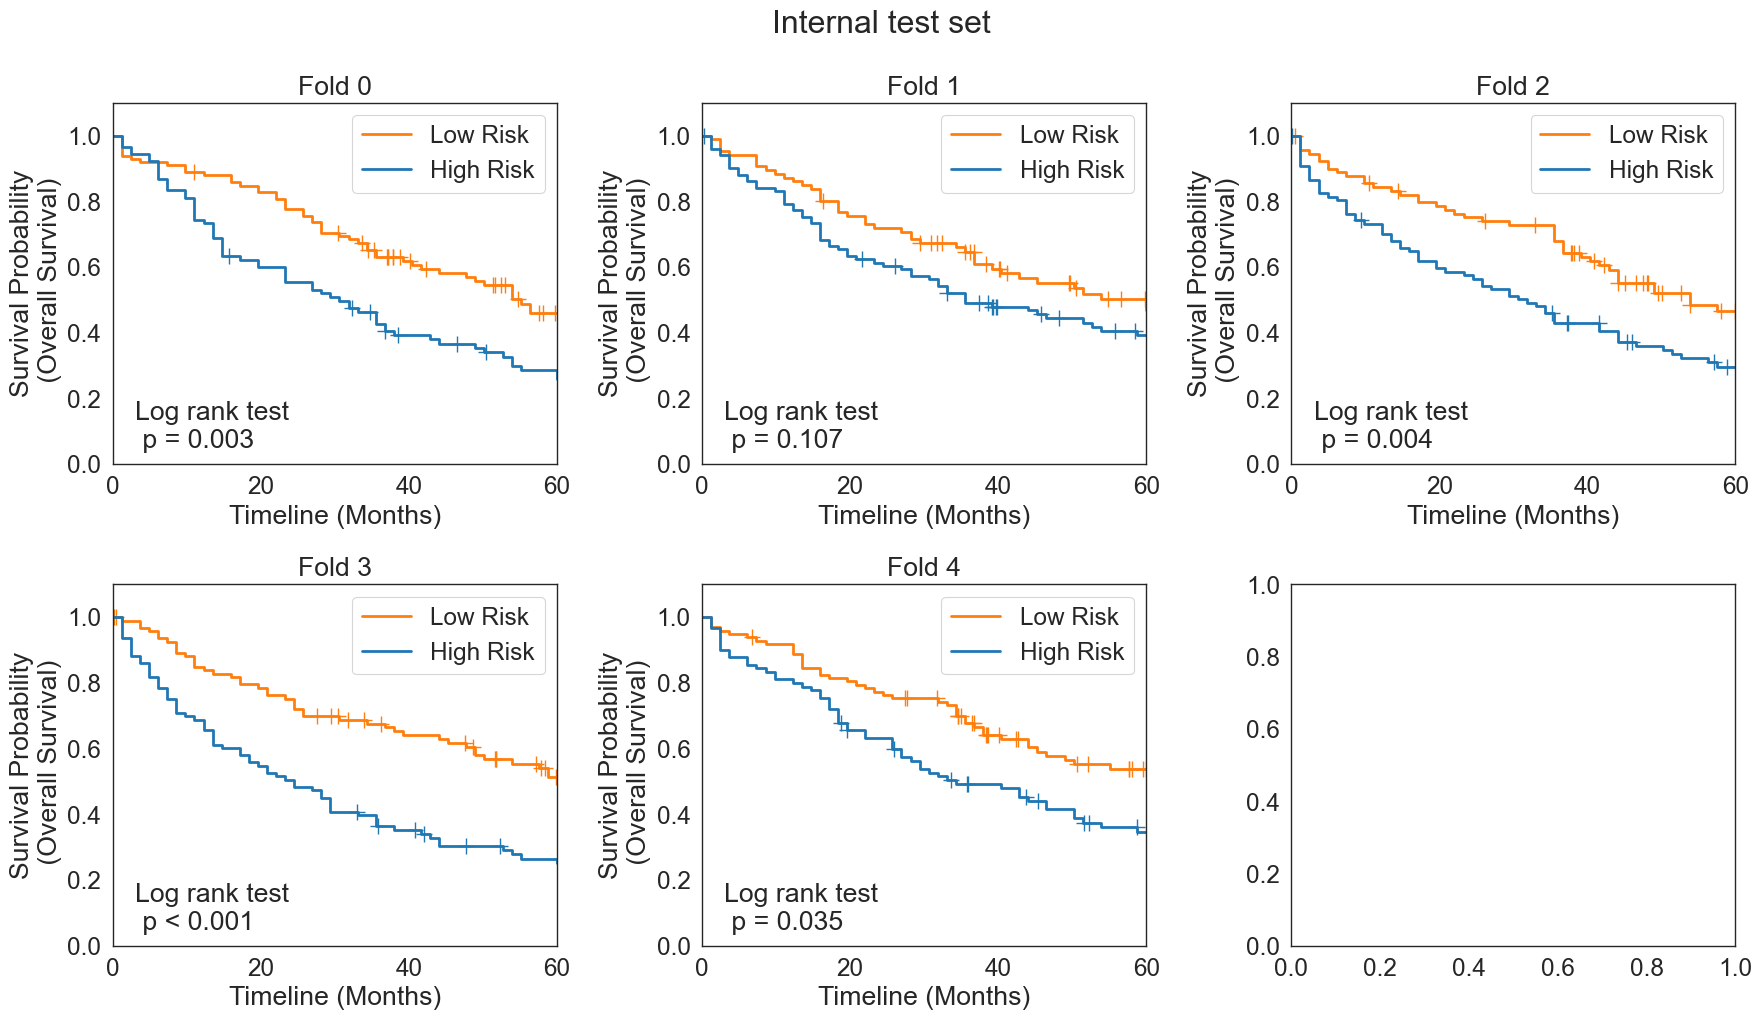

In [45]:
sns.set_theme(style='white')
sns.set_context(context='paper', font_scale=2.0)

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18,10.5))
axs = axs.flatten()

for i in range(num_folds):
    risk_groups = high_low[i]
    risk_groups = risk_groups[risk_groups['original_set'] == 'test']
    plot_km_two_groups(risk_groups, event_ind_field, event_data_field, f'h_bin_{i}', 60, add_counts=False, title=f'Fold {i}', ci_show=False, ax=axs[i])
# plot_km_two_groups(additional_risk_groups, event_ind_field, event_data_field, 'risk', 60, title='External test set', ax=ax2)

plt.suptitle('Internal test set')
plt.tight_layout()
plt.show()

p < 0.001
p = 0.003
p = 0.003
p = 0.01
p = 0.001


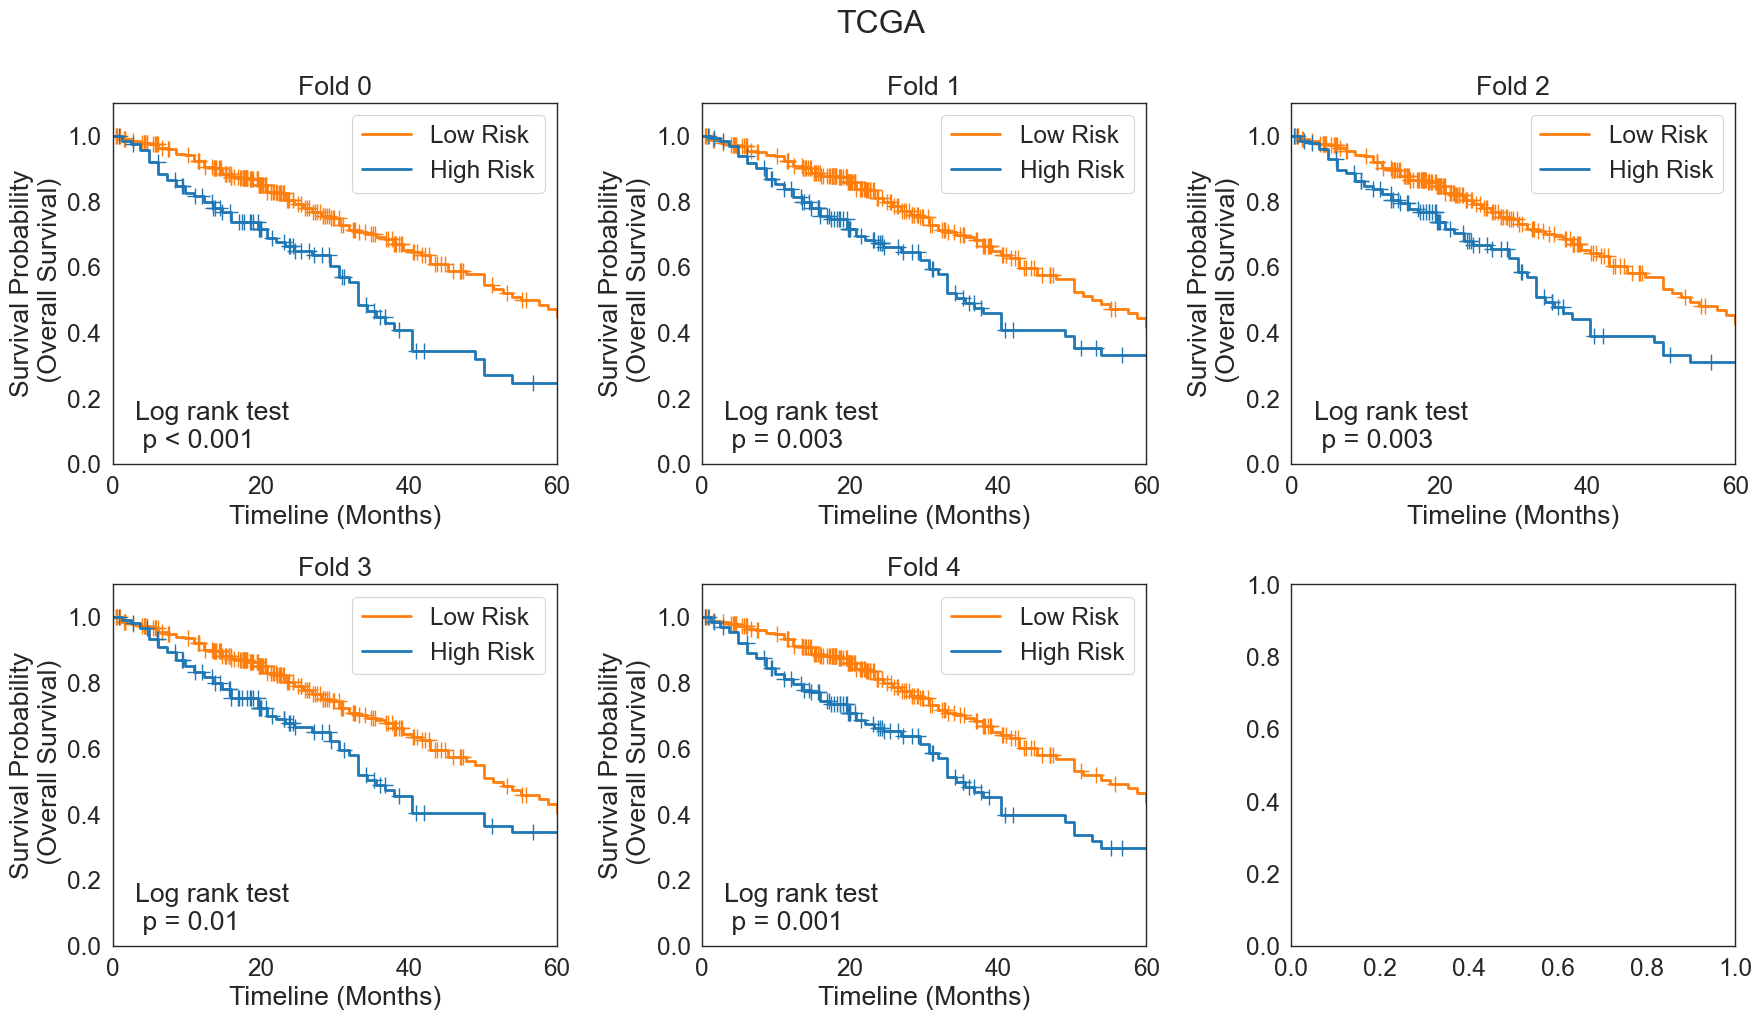

In [46]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18,10.5))
axs = axs.flatten()

for i in range(num_folds):
    risk_groups = high_low[i]
    risk_groups = risk_groups[risk_groups['original_set'] == 'additional']
    plot_km_two_groups(risk_groups, event_ind_field, event_data_field, f'h_bin_{i}', 60, add_counts=False, title=f'Fold {i}', ci_show=False, ax=axs[i])
# plot_km_two_groups(additional_risk_groups, event_ind_field, event_data_field, 'risk', 60, title='External test set', ax=ax2)

plt.suptitle('TCGA')
plt.tight_layout()
plt.show()

### SHAP Values

In [75]:
import pickle

for fold in range(5):
    with open(os.path.join(alpha_path, f'cph_fold_{fold}.pkl'), 'wb') as file:
        pickle.dump(cph_models[fold], file)

In [ ]:
import shap

fold = 1

train, test, additional = data_dict[fold]['train_X'], data_dict[fold]['test_X'], data_dict[fold]['additional_X']
explainer = shap.explainers.Permutation(cph_models[fold].predict_partial_hazard, train)
train_explanation = explainer(train)

PermutationExplainer explainer: 754it [00:15, 17.81it/s]                         


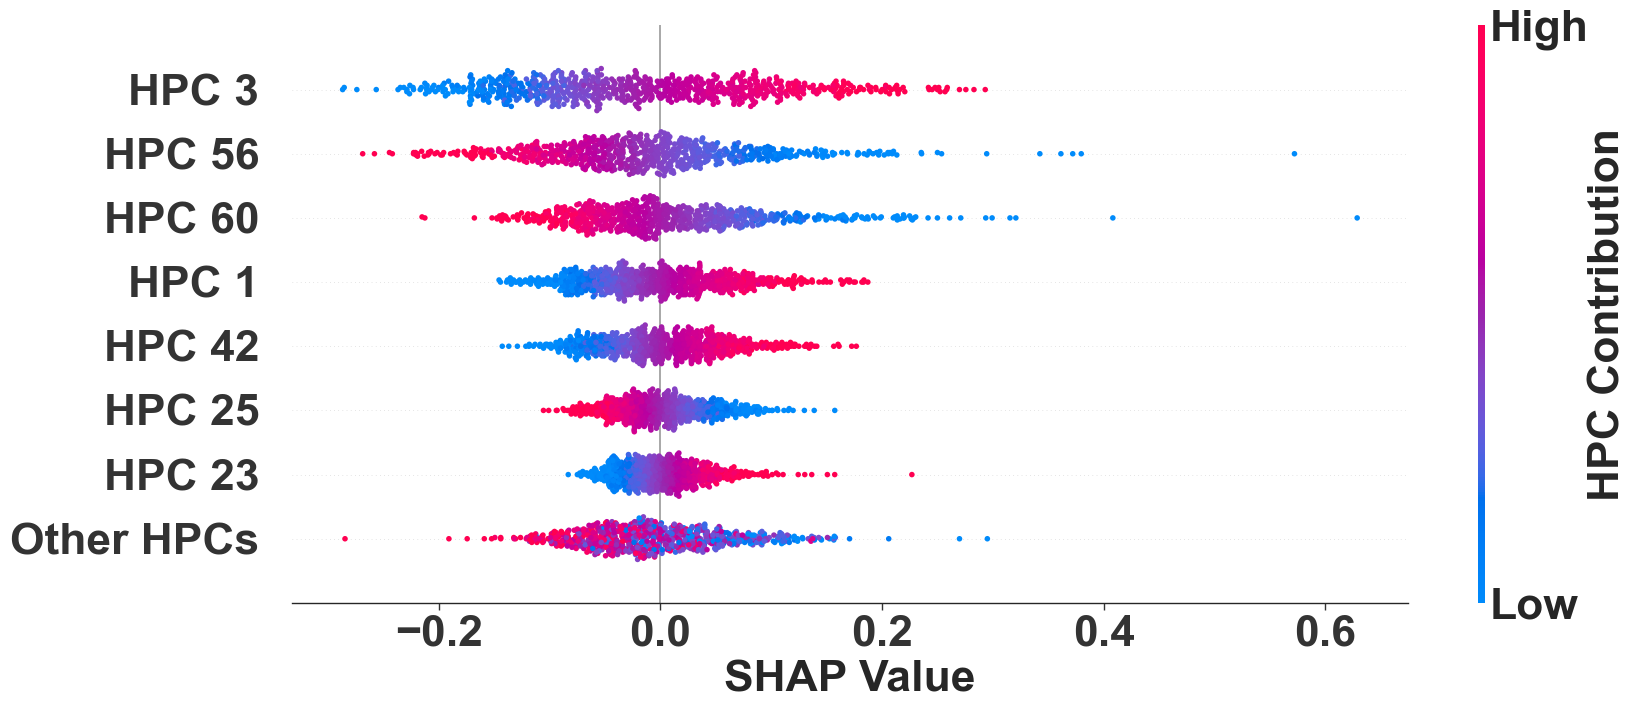

In [66]:
fontsize = 32
shap.plots.beeswarm(train_explanation, max_display=8, show=False, plot_size=(18,7.5))

figure = plt.gcf()
figure.axes[0].set_xlabel('SHAP Value', fontsize=fontsize, fontdict={'fontweight':'bold'})
figure.axes[1].set_ylabel('HPC Contribution', fontsize=fontsize, fontdict={'fontweight':'bold'})

for ax in [figure.axes[0], figure.axes[1]]:
		for tick in ax.xaxis.get_major_ticks():
			tick.label1.set_fontweight('bold')
			tick.label2.set_fontweight('bold')
			tick.label1.set_fontsize(fontsize)
			tick.label2.set_fontsize(fontsize)
		for tick in ax.yaxis.get_major_ticks():
			tick.label1.set_fontweight('bold')
			tick.label2.set_fontweight('bold')
			tick.label1.set_fontsize(fontsize)
			tick.label2.set_fontsize(fontsize)

# For all abnormal
# figure.axes[0].set_yticklabels(labels=['HPC 27', 'HPC 0', 'HPC 30', 'HPC 13', 'HPC 56', 'HPC 1', 'HPC 59', 'HPC 48', 'HPC 64', 'HPC 41', 'HPC 69', 'HPC 21', 'HPC 2', 'Other HPCs'][::-1])

# For malignant
# figure.axes[0].set_yticklabels(labels=['HPC 27', 'HPC 69', 'HPC 0', 'HPC 30', 'HPC 41', 'HPC 13', 'HPC 48', 'HPC 64', 'HPC 21', 'HPC 33', 'HPC 5', 'HPC 44', 'HPC 40', 'Other HPCs'][::-1])

# For stroma
# figure.axes[0].set_yticklabels(labels=['HPC 3', 'HPC 56', 'HPC 42', 'HPC 60', 'HPC 1', 'HPC 25', 'HPC 16', 'Other HPCs'][::-1])
figure.axes[0].set_yticklabels(labels=['HPC 3', 'HPC 56', 'HPC 60', 'HPC 1', 'HPC 42', 'HPC 25', 'HPC 23', 'Other HPCs'][::-1])

plt.savefig(os.path.join(alpha_path, f'shap_fold_{fold}.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [67]:
explainer = shap.explainers.Permutation(cph_models[fold].predict_partial_hazard, test)
test_explanation = explainer(test)

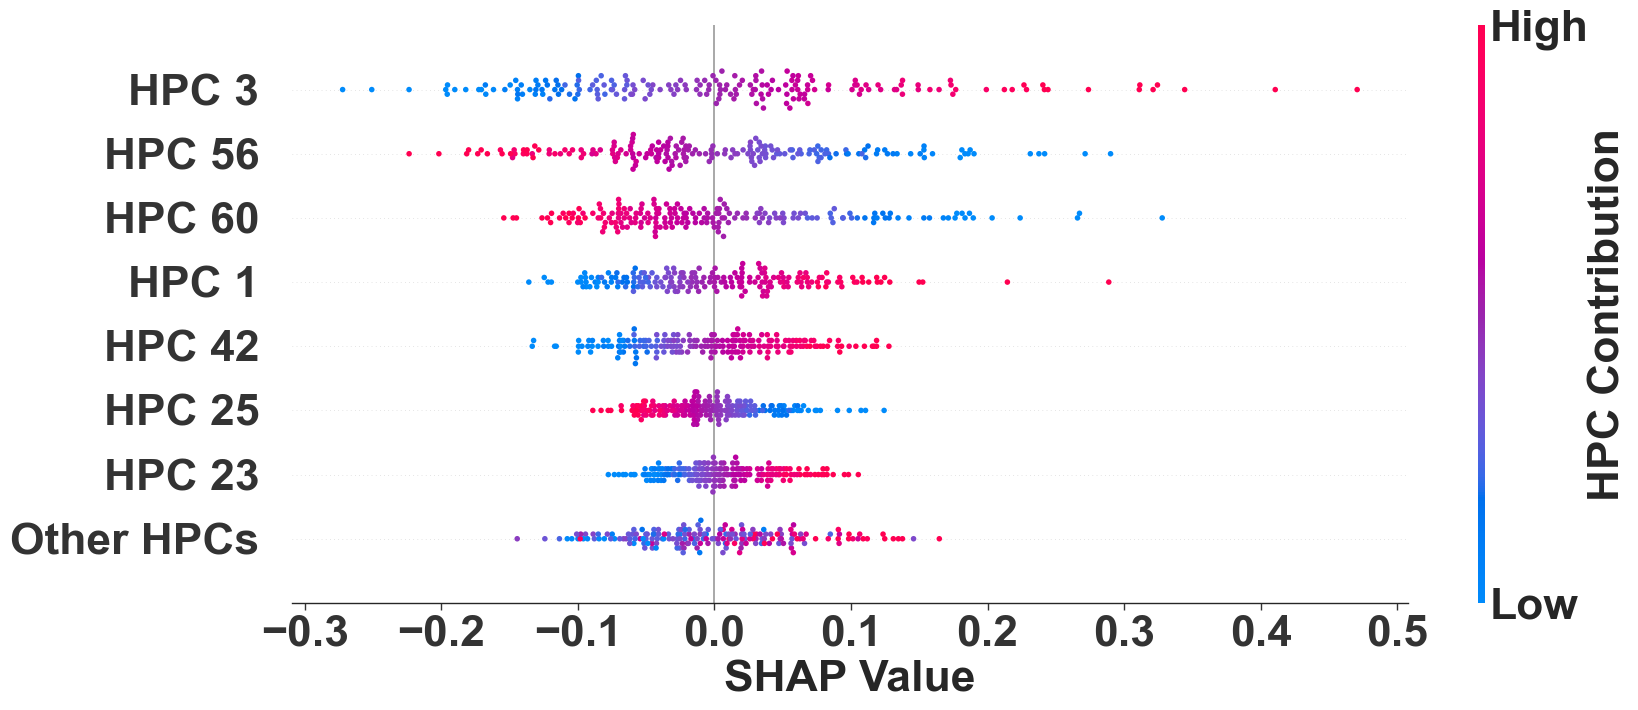

In [69]:
fontsize = 32
shap.plots.beeswarm(test_explanation, max_display=8, show=False, plot_size=(18,7.5))

figure = plt.gcf()
figure.axes[0].set_xlabel('SHAP Value', fontsize=fontsize, fontdict={'fontweight':'bold'})
figure.axes[1].set_ylabel('HPC Contribution', fontsize=fontsize, fontdict={'fontweight':'bold'})

for ax in [figure.axes[0], figure.axes[1]]:
		for tick in ax.xaxis.get_major_ticks():
			tick.label1.set_fontweight('bold')
			tick.label2.set_fontweight('bold')
			tick.label1.set_fontsize(fontsize)
			tick.label2.set_fontsize(fontsize)
		for tick in ax.yaxis.get_major_ticks():
			tick.label1.set_fontweight('bold')
			tick.label2.set_fontweight('bold')
			tick.label1.set_fontsize(fontsize)
			tick.label2.set_fontsize(fontsize)

# All abnormal
# figure.axes[0].set_yticklabels(labels=['HPC 27', 'HPC 0', 'HPC 30', 'HPC 13', 'HPC 56', 'HPC 1', 'HPC 64', 'HPC 59', 'HPC 48', 'HPC 41', 'HPC 69', 'HPC 2', 'HPC 21', 'Other HPCs'][::-1])

# Malignant
# figure.axes[0].set_yticklabels(labels=['HPC 27', 'HPC 0', 'HPC 69', 'HPC 30', 'HPC 13', 'HPC 41', 'HPC 48', 'HPC 64', 'HPC 33', 'HPC 21', 'HPC 5', 'HPC 40', 'HPC 44', 'Other HPCs'][::-1])

# For stroma
# figure.axes[0].set_yticklabels(labels=['HPC 3', 'HPC 56', 'HPC 42', 'HPC 60', 'HPC 1', 'HPC 25', 'HPC 16', 'Other HPCs'][::-1])
figure.axes[0].set_yticklabels(labels=['HPC 3', 'HPC 56', 'HPC 60', 'HPC 1', 'HPC 42', 'HPC 25', 'HPC 23', 'Other HPCs'][::-1])

plt.savefig(os.path.join(alpha_path, f'shap_fold_{fold}_test.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()


In [70]:
# additional_explanation = explainer(additional)

explainer = shap.explainers.Permutation(cph_models[fold].predict_partial_hazard, additional)
additional_explanation = explainer(additional)

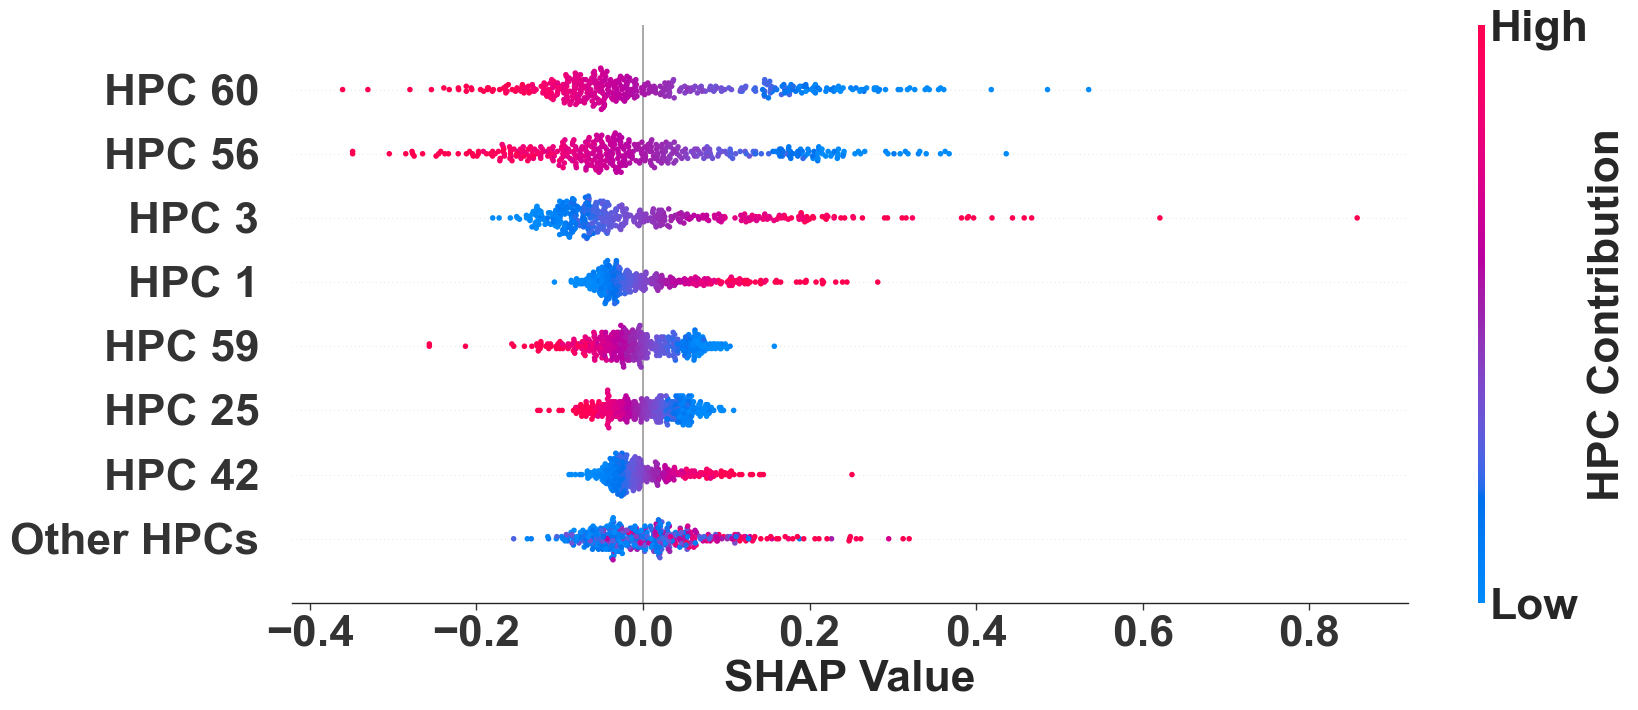

In [72]:
fontsize = 32
shap.plots.beeswarm(additional_explanation, max_display=8, show=False, plot_size=(18,7.5))

figure = plt.gcf()
figure.axes[0].set_xlabel('SHAP Value', fontsize=fontsize, fontdict={'fontweight':'bold'})
figure.axes[1].set_ylabel('HPC Contribution', fontsize=fontsize, fontdict={'fontweight':'bold'})

for ax in [figure.axes[0], figure.axes[1]]:
		for tick in ax.xaxis.get_major_ticks():
			tick.label1.set_fontweight('bold')
			tick.label2.set_fontweight('bold')
			tick.label1.set_fontsize(fontsize)
			tick.label2.set_fontsize(fontsize)
		for tick in ax.yaxis.get_major_ticks():
			tick.label1.set_fontweight('bold')
			tick.label2.set_fontweight('bold')
			tick.label1.set_fontsize(fontsize)
			tick.label2.set_fontsize(fontsize)

# All abnormal
# figure.axes[0].set_yticklabels(labels=['HPC 27', 'HPC 30', 'HPC 59', 'HPC 13', 'HPC 56', 'HPC 0', 'HPC 69', 'HPC 64', 'HPC 1', 'HPC 48', 'HPC 41', 'HPC 60', 'HPC 33', 'Other HPCs'][::-1])

# Malignant
# figure.axes[0].set_yticklabels(labels=['HPC 27', 'HPC 69', 'HPC 30', 'HPC 0', 'HPC 13', 'HPC 41', 'HPC 48', 'HPC 64', 'HPC 33', 'HPC 21', 'HPC 5', 'HPC 40', 'HPC 44', 'Other HPCs'][::-1])

# For stroma
# figure.axes[0].set_yticklabels(labels=['HPC 56', 'HPC 3', 'HPC 60', 'HPC 25', 'HPC 42', 'HPC 1', 'HPC 59', 'Other HPCs'][::-1])
figure.axes[0].set_yticklabels(labels=['HPC 60', 'HPC 56', 'HPC 3', 'HPC 1', 'HPC 59', 'HPC 25', 'HPC 42', 'Other HPCs'][::-1])
plt.savefig(os.path.join(alpha_path, f'shap_fold_{fold}_additional.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)

plt.show()


In [62]:
def plot_forest(
    feature_names,
    estimates,
    ci_lower,
    ci_upper,
    p_values,
    *,
    reference=1.0,
    x_label="Hazard ratio (95% CI)",
    marker_kwargs=None,
    error_kwargs=None,
    table_headers=("95% CI", "p"),
    figsize=None,
):
    feature_names = list(feature_names)
    n_features = len(feature_names)

    estimates = np.asarray(estimates, dtype=float)
    ci_lower = np.asarray(ci_lower, dtype=float)
    ci_upper = np.asarray(ci_upper, dtype=float)
    p_values = np.asarray(p_values, dtype=float)

    if not (len(estimates) == len(ci_lower) == len(ci_upper) == len(p_values) == n_features):
        raise ValueError("All input arrays must match feature_names length.")

    if figsize is None:
        figsize = (7, 0.45 * n_features + 1.5)

    default_marker = {"fmt": "s", "color": "black", "markersize": 6, "mec": "black"}
    default_error = {"ecolor": "black", "elinewidth": 1.4, "capsize": 3, "capthick": 1.2}
    marker_kwargs = {**default_marker, **(marker_kwargs or {})}
    error_kwargs = {**default_error, **(error_kwargs or {})}

    fig, axes_arr = plt.subplots(
        ncols=2,
        sharey=True,
        figsize=figsize,
        gridspec_kw={"width_ratios": [0.7, 0.3]},
    )
    ax_forest, ax_table = axes_arr

    y_positions = np.arange(n_features)[::-1]

    # Middle forest plot
    error_offsets = np.vstack([estimates - ci_lower, ci_upper - estimates])
    ax_forest.errorbar(estimates, y_positions, xerr=error_offsets, **marker_kwargs, **error_kwargs)
    ax_forest.axvline(reference, color="grey", linewidth=1.15, linestyle="--")
    ax_forest.set_xlabel(x_label)
    ax_forest.set_yticks(y_positions)
    ax_forest.set_yticklabels(feature_names)
    ax_forest.set_ylim(-0.5, n_features - 0.5)
    ax_forest.set_xlim([min(ci_lower) - 0.2, max(ci_upper) + 0.2])
    ax_forest.set_ylabel('Cluster')

    for ax in [ax_forest]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_visible(True)
        ax.spines["left"].set_visible(False)

    # Right: two-column text (CI | p-value)
    def format_interval(lo, hi):
        return f"({lo:.2f} – {hi:.2f})"

    def format_p(p):
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "<0.001"
        return f"{p:.3f}"

    ax_table.set_xlim(0, 1)
    ax_table.set_ylim(-0.5, n_features - 0.5)
    ax_table.axis("off")

    ci_x, p_x = 0.1, 0.75  # tweak to taste

    ax_table.text(ci_x, n_features - 0.3, table_headers[0], va="bottom", ha="center", fontsize=11, fontweight="bold")
    ax_table.text(p_x, n_features - 0.3, table_headers[1], va="bottom", ha="center", fontsize=11, fontweight="bold")

    for y, lo, hi, p in zip(y_positions, ci_lower, ci_upper, p_values):
        ax_table.text(ci_x, y, format_interval(lo, hi), va="center", ha="center", fontsize=10)
        ax_table.text(p_x, y, format_p(p), va="center", ha="center", fontsize=10)

    fig.tight_layout()
    return fig, {"forest": ax_forest, "table": ax_table}
    # return fig, {"labels": ax_labels, "forest": ax_forest, "table": ax_table}


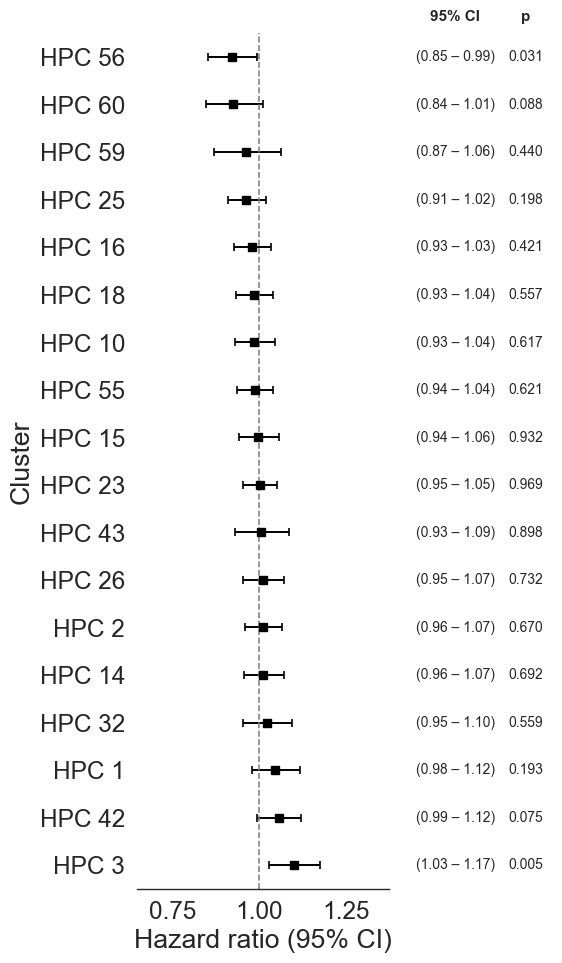

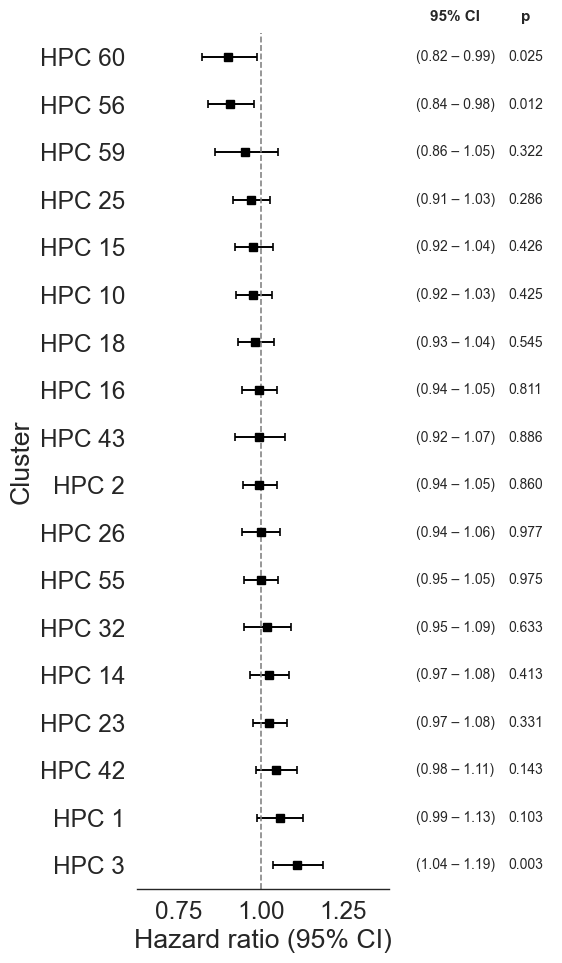

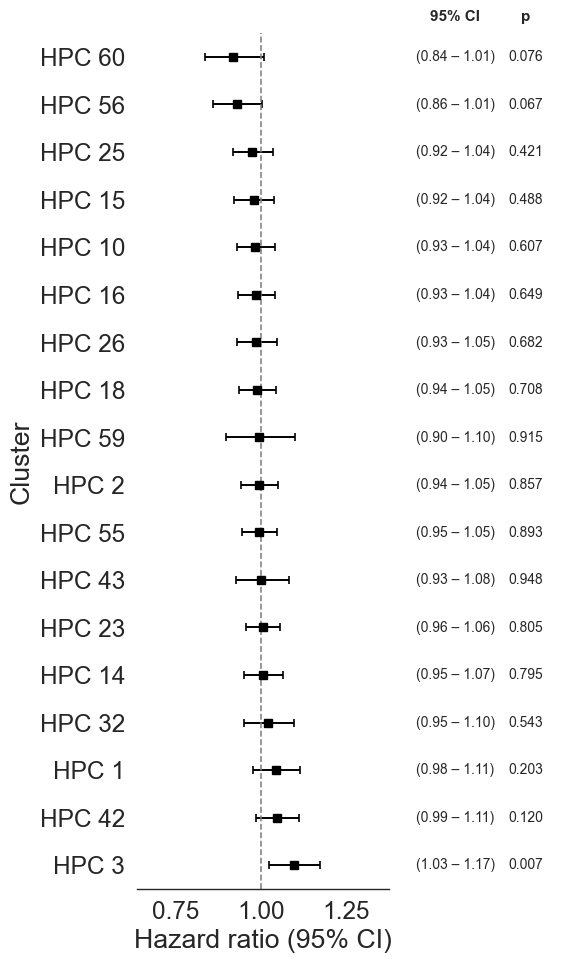

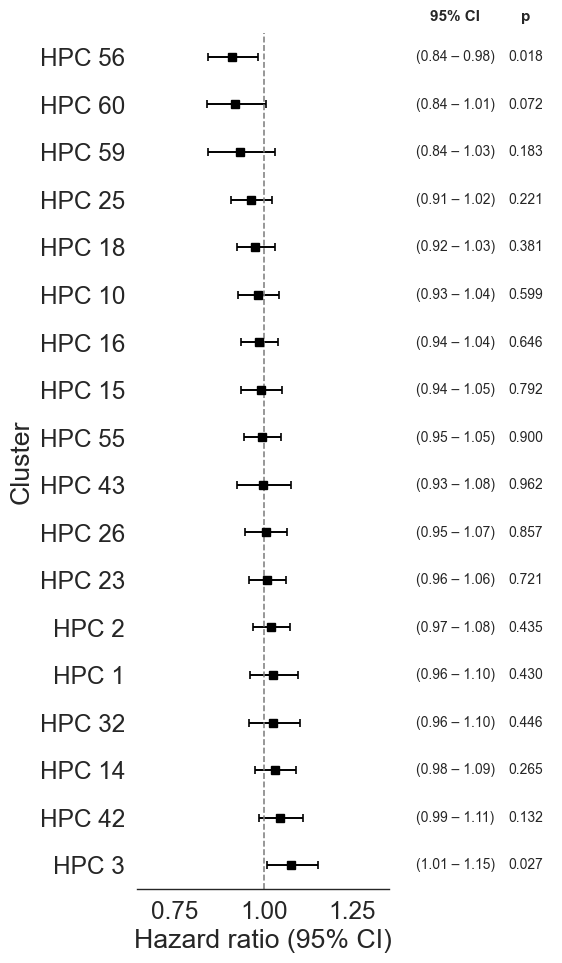

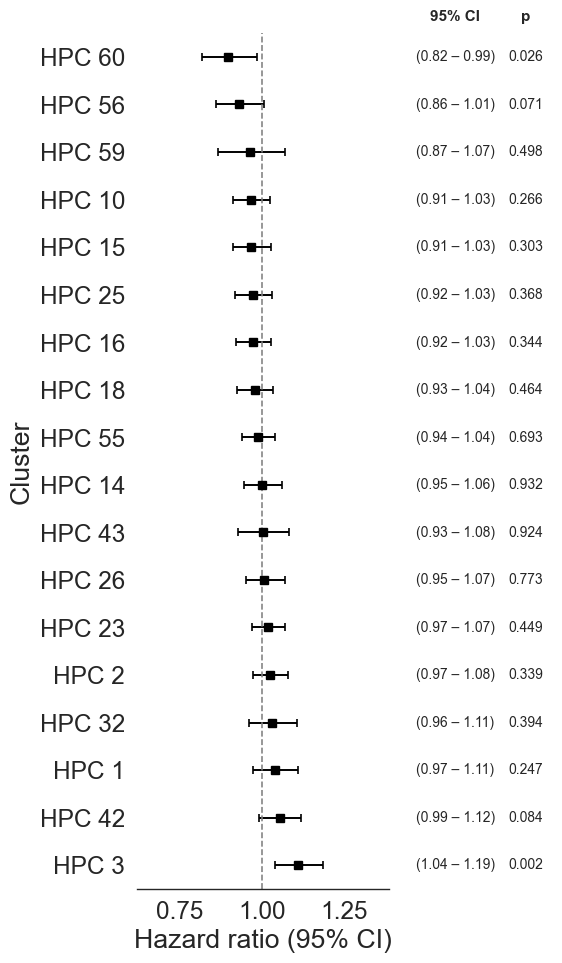

In [63]:
for fold in range(5):

    os_stroma = pd.read_csv(os.path.join(alpha_path, f'os_event_ind_fold_{fold}.csv'))

    os_stroma['covariate'] = [f'HPC {c}' for c in os_stroma['covariate']]
    results_dir = os.path.join(main_path, 'data/vanilla-hpc')

    plot_forest(feature_names=os_stroma['covariate'],
                    estimates=os_stroma['exp(coef)'],
                    ci_lower=os_stroma['exp(coef) lower 95%'],
                    ci_upper=os_stroma['exp(coef) upper 95%'],
                    p_values=os_stroma['p'],
                    figsize=(6,10))
        
    # plt.savefig(os.path.join(main_path, results_dir, f'os_fold_0_stroma_hpc.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)